## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.

Original evalscript: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/oil-spill-index/

Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)

Conversion: Development Seed (openEO-UDP project)

# OSI - Oil Spill Index

This notebook demonstrates an Oil Spill Index (OSI) workflow for Sentinel-2 coastal and marine scenes, using the following ratio:

$$\text{OSI} = \frac{(B_{03} + B_{04})}{(B_{02})}$$

Where: 
- B02 (492.4 nm): Blue band
- B03 (559.8 nm): Green band
- B04 (664.6 nm): Red band

The OSI ratio enhances potential oil slick signatures over water. The original Evalscript includes grayscale OSI rendering and RGB band-ratio visualizations, but this notebook focuses on false-color RGB where oil/water contrast can be easier to interpret than grayscale:

$$\text{Red} = \frac{(B_{05} + B_{06})}{(B_{07})}$$
$$\text{Green} = \frac{(B_{03} + B_{04})}{(B_{02})}$$
$$\text{Blue} = \frac{(B_{11} + B_{12})}{(B_{08})}$$

Where: 
- B05 (704.1 nm): Vegetation red edge
- B06 (740.5 nm): Vegetation red edge
- B07 (782.8 nm): Vegetation red edge
- B08 (832.8 nm): NIR
- B11 (1613.7 nm): SWIR
- B12 (2202.4 nm): SWIR

The outputs are intended for rapid screening and should be validated with contextual information and additional analysis to avoid confusion with look-alike phenomena (e.g. sunglint, algae, or sediments).

## Overview

In this notebook, we will:
1. Connect to CDSE openEO backend service (https://openeo.dataspace.copernicus.eu/)
2. Define an area of interest containing the marine environment
3. Load Sentinel-2-L2A imagery 
4. Calculate OSI 
5. Generate an RGB visualization

## Import Required Libraries

We begin by importing the necessary Python libraries for data processing and visualization.

In [2]:
import openeo
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
from openeo.processes import array_create

## Connect to CDSE OpenEO Backend

Connect to the OpenEO backend and authenticate using OpenID Connect.

In [16]:
connection = openeo.connect(
    url="https://openeo.dataspace.copernicus.eu/"
).authenticate_oidc()

Authenticated using refresh token.


## Define Area of Interest

Define the spatial extent for our analysis. This example uses coordinates of Mauritios shore.

In [17]:
spatial_extent = {"west": 57.70, "south": -20.45, "east": 57.77, "north": -20.41}

## Load Sentinel-2 Data

Load Sentinel-2 L2A (bottom-of-atmosphere reflectance) data.

In [18]:
s2cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=spatial_extent,
    temporal_extent=["2020-07-17", "2020-09-06"], 
    bands=[
        "B02",
        "B03",
        "B04",
        "B05",
        "B06",
        "B07",
        "B08",
        "B11",
        "B12"
    ],
)

# Scale digital numbers to reflectance [0, 1]
s2cube = s2cube / 10000

# Define several timestamps for data comparison
before_oil_spill = s2cube.filter_temporal(["2020-07-17"]).reduce_dimension(dimension="t", reducer="first")
oil_spill = s2cube.filter_temporal(["2020-08-01"]).reduce_dimension(dimension="t", reducer="first")
dissolute_oil_spill = s2cube.filter_temporal(["2020-08-06"]).reduce_dimension(dimension="t", reducer="first")

# Use a wider post-spill window and take the latest available scene.
after_oil_spill = s2cube.filter_temporal(["2020-08-30", "2020-09-06"]).reduce_dimension(dimension="t", reducer="last")

## Define RGB visualization for oil spill

In [19]:
def oil_spill_viz(data):
    B02, B03, B04, B05, B06, B07, B08, B11, B12 = (
        data[0],
        data[1],
        data[2],
        data[3],
        data[4],
        data[5],
        data[6],
        data[7],
        data[8]
    )

    red = (B05 + B06) / B07
    green = (B03 + B04) / B02 # OSI
    blue = (B11 + B12) / B08

    osi_viz = array_create([red / 3, green / 3, blue / 3])

    return osi_viz

In [20]:
before_oil_spill_image = before_oil_spill.apply_dimension(dimension="bands", process=oil_spill_viz)
oil_spill_image = oil_spill.apply_dimension(dimension="bands", process=oil_spill_viz)
dissolute_oil_spill_image = dissolute_oil_spill.apply_dimension(dimension="bands", process=oil_spill_viz)
after_oil_spill_image = after_oil_spill.apply_dimension(dimension="bands", process=oil_spill_viz)

In [21]:
run_job_list = ["before_oil_spill_image", "oil_spill_image", "dissolute_oil_spill_image", "after_oil_spill_image"]

for job in run_job_list:
    output_file = Path(f"{job}.png")

    if output_file.exists():
        print(f"Skipping job (already exists): {output_file}")
        continue

    print(f"Running job: {job}")
    globals()[job] = globals()[job].linear_scale_range(0, 1, 0, 255)
    globals()[job].download(str(output_file))
    print(f"Finished: {job}")

Skipping job (already exists): before_oil_spill_image.png
Skipping job (already exists): oil_spill_image.png
Skipping job (already exists): dissolute_oil_spill_image.png
Running job: after_oil_spill_image
Finished: after_oil_spill_image


## Visualization

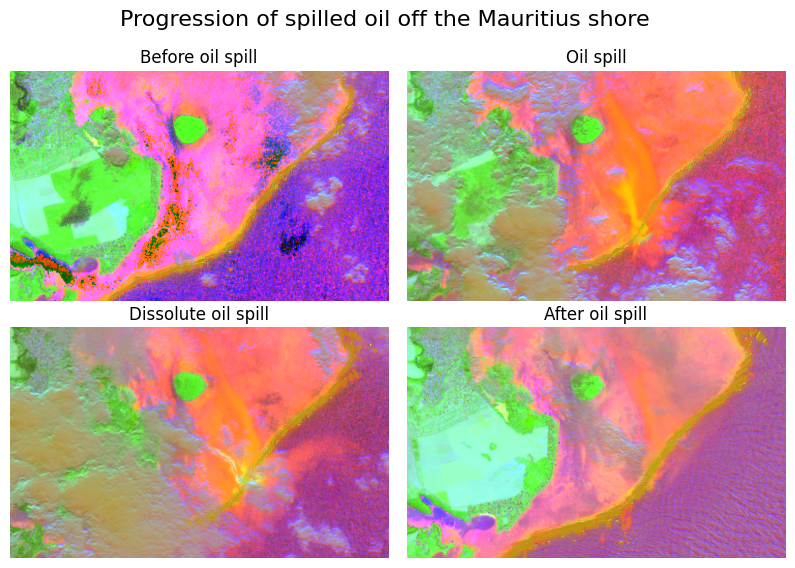

In [29]:
# Load and display the image
image_list = ["before_oil_spill_image", "oil_spill_image", "dissolute_oil_spill_image", "after_oil_spill_image"]

fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=100)

fig.suptitle(
    "Progression of spilled oil off the Mauritius shore",
    fontsize=16,
    y=0.80
)

fig.subplots_adjust(hspace=-0.5, wspace=0.05)

for ax, image in zip(axes.ravel(), image_list):
    title = image.split("_")[:-1]
    title = " ".join(title).capitalize()

    img = Image.open(f"{image}.png")
    ax.imshow(img)
    ax.set_title(
        title,
        fontsize=12,
    )
    ax.axis("off")

# plt.tight_layout()
plt.show()

## Performance and Limitations

- **Computation:** Lightweight, only band ratios on a few reflectance bands, so it is cheap to run at scale in openEO.
- **Discrimination:** Oil is not uniquely identified by OSI alone; dark water, clouds or haze, river plumes, suspended sediment, and algal blooms can mimic or mask slicks.
- **Geometry and timing:** Results depend on sea state, and oil thickness and age; compare multiple dates and adjacent clear areas when possible.

## Recommended Practices

- Cross-check with **context**: shipping lanes, known discharge events
- Use **complementary data**: SAR (e.g. Sentinel-1) for surface roughness independent of daylight; other spectral indices or masks for vegetation, land, and clouds.
- Prefer **cloud-free** pixels and provide **temporal baselines** (pre-event vs post-event or multi-date composites) to reduce false positives.

## Citation
Rajendran, S., Sadooni, F.N., Saad, H.A., Oleg, A., Govil, H., Nasir, S, Vethamony, P. (2021). *Monitoring oil spill in Norilsk, Russia using satellite data*. **Scientific Reports**. 11, 3817.

Rajendran, S., Vethamony, P., Sadooni, F.N., Saad, H.A., Al-Khayat, J.A., Govil, H., Nasir, S. (2021). *Sentinel-2 image transformation methods for mapping oil spill - A case study with Wakashio oil spill in the Indian Ocean, off Mauritius*. **MethodsX** 101327.

Rajendran, S., Vethamony, P., Sadooni, F.N., Saad, H.A., Al-Khayat, J.A., Seegobin, V.O., Govil, H., Nasir, S. (2021). *Detection of Wakashio oil spill off Mauritius using Sentinel-1 and 2 data: Capability of sensors, image transformation methods and mapping*. **Environmental Pollution**. 274, 116618.

## Attribution

This openEO User-Defined Process is a conversion of the original Sentinel Hub evalscript:

**Original Script:** [OSI - Oil Spill Index)](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/oil-spill-index/)

**Author:** Sankaran Rajendran

**Source Repository:** [Sentinel Hub Custom Scripts](https://github.com/sentinel-hub/custom-scripts)

This conversion maintains the scientific methodology and visualization approach of the original evalscript while adapting it to the openEO process graph framework for interoperability across openEO-compliant backends.